In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score

In [2]:
TOPSIS_data = pd.read_excel('D:/Kerjaan/Project P64180125 (k-Means, DBSCAN and TOPSIS in Python)/Post Revisi/TOPSIS Data Frame.xlsx',index_col=0)

In [3]:
Clust_data = pd.read_excel('D:/Kerjaan/Project P64180125 (k-Means, DBSCAN and TOPSIS in Python)/Post Revisi/Clustering Data Frame.xlsx',index_col=0)

In [4]:
TOPSIS_data.shape

(13, 14)

In [5]:
# 2. Tahap TOPSIS
# Menentukan bobot kriteria (contoh: semua fitur sama penting)
criteria_weight  = np.array([1/14] * 14)

criteria_matrix = TOPSIS_data.iloc[:,1:]

# Criteria preference can be set based on domain knowledge or cluster characteristics
criteria_preference = np.ones(criteria_matrix.shape[1])

In [6]:
criteria_matrix = np.array(criteria_matrix, dtype=np.float64)
column_sums = (criteria_matrix ** 2).sum(axis=0)
with np.errstate(divide='ignore', invalid='ignore'): # Suppress warnings for division by zero
    norm_matrix = criteria_matrix / np.sqrt(column_sums)
    norm_matrix = np.nan_to_num(norm_matrix) #Handle NaN values resulting from division by zero

In [7]:
def weighted_matrix(criteria_weight, normalized_matrix):
    normalized_rows = len(normalized_matrix)
    normalized_columns = len(normalized_matrix[0])

    weighted_matrix = []
    for i in range(normalized_rows):
        weighted_matrix_rows = []
        for j in range(normalized_columns):
            weighted_matrix_rows.append(normalized_matrix [i][j]* criteria_weight[j])
        weighted_matrix.append(weighted_matrix_rows)

    print('\nWeighted matrix from normalized matrix: ')
    for i in weighted_matrix:
        for j in i:
            print(f'{j:.4f}',end=' ')
        print()
    return weighted_matrix

In [8]:
weighted_matrix = weighted_matrix(criteria_weight.flatten(),norm_matrix)


Weighted matrix from normalized matrix: 
0.0241 0.0000 0.0000 0.0000 0.0006 0.0000 0.0312 0.0247 0.0292 0.0059 0.0000 0.0180 0.0224 
0.0048 0.0109 0.0136 0.0121 0.0300 0.0017 0.0190 0.0123 0.0000 0.0117 0.0000 0.0211 0.0230 
0.0054 0.0000 0.0000 0.0000 0.0025 0.0001 0.0068 0.0159 0.0000 0.0059 0.0000 0.0167 0.0166 
0.0161 0.0000 0.0000 0.0000 0.0042 0.0010 0.0054 0.0194 0.0000 0.0000 0.0000 0.0216 0.0181 
0.0197 0.0000 0.0000 0.0000 0.0031 0.0001 0.0027 0.0159 0.0000 0.0000 0.0000 0.0152 0.0242 
0.0226 0.0000 0.0000 0.0000 0.0015 0.0000 0.0054 0.0035 0.0292 0.0294 0.0000 0.0163 0.0179 
0.0042 0.0235 0.0215 0.0191 0.0316 0.0027 0.0014 0.0247 0.0000 0.0000 0.0000 0.0223 0.0271 
0.0000 0.0651 0.0665 0.0675 0.0168 0.0040 0.0041 0.0176 0.0000 0.0235 0.0693 0.0208 0.0277 
0.0363 0.0036 0.0019 0.0018 0.0109 0.0001 0.0081 0.0000 0.0000 0.0059 0.0000 0.0205 0.0134 
0.0276 0.0036 0.0046 0.0045 0.0441 0.0712 0.0394 0.0493 0.0583 0.0352 0.0000 0.0212 0.0144 
0.0312 0.0127 0.0033 0.0035 0.0122 0.0

In [9]:
def ideal_best_worst(weighted_matrix,criteria_preferences):
    weighted_column = len(weighted_matrix[0])
    positive_ideal= []
    negative_ideal = []

    for j in range(weighted_column):
        max_value = weighted_matrix[0][j]
        min_value = weighted_matrix[0][j]

        for i in range(len(weighted_matrix)):
            if weighted_matrix[i][j] > max_value:
                max_value = weighted_matrix [i][j]
            if weighted_matrix[i][j] < min_value:
                min_value = weighted_matrix [i][j]
        if criteria_preferences[j] == 1:
            positive_ideal.append(max_value)
            negative_ideal.append(min_value)
        else:
            positive_ideal.append(min_value)
            negative_ideal.append(max_value)

    print('\nPositive ideal point for each column: ')
    for i in positive_ideal:
        print(f'{i:.4f}',end=' ')
    print()
    print('\nNegative ideal point for each column: ')
    for i in negative_ideal:
        print(f'{i:.4f}',end=' ')
    print()

    return positive_ideal, negative_ideal

In [10]:
ideal = ideal_best_worst(weighted_matrix,criteria_preference)


Positive ideal point for each column: 
0.0363 0.0651 0.0665 0.0675 0.0441 0.0712 0.0394 0.0493 0.0583 0.0470 0.0693 0.0223 0.0277 

Negative ideal point for each column: 
0.0000 0.0000 0.0000 0.0000 0.0006 0.0000 0.0014 0.0000 0.0000 0.0000 0.0000 0.0152 0.0134 


In [11]:
def separation_from_ideal_point(weighted_matrix,positive_ideal,negative_ideal):
    weighted_rows = len(weighted_matrix)
    positive_separation = []
    negative_separation = []

    for i in range(weighted_rows):
        pos_sep = 0
        neg_sep = 0
        for j in range(len(positive_ideal)):
            pos_sep += (weighted_matrix[i][j] - positive_ideal[j]) ** 2
            neg_sep += (weighted_matrix[i][j] - negative_ideal[j]) ** 2
        positive_separation.append(pos_sep ** 0.5)
        negative_separation.append(neg_sep ** 0.5)

    print('\nPositive separation: ')
    for i in (positive_separation):
        print(f'{i:.4f}')
    print('\nNegative separation: ')
    for i in (negative_separation):
        print(f'{i:.4f}')
    return positive_separation,negative_separation

In [12]:
separation = separation_from_ideal_point(weighted_matrix,ideal[0],ideal[1])


Positive separation: 
0.1685
0.1615
0.1822
0.1808
0.1821
0.1721
0.1564
0.1131
0.1787
0.1295
0.1739
0.1796
0.1664

Negative separation: 
0.0553
0.0455
0.0190
0.0270
0.0276
0.0477
0.0567
0.1393
0.0394
0.1278
0.0412
0.0368
0.0605


In [13]:
def similarities_to_PIS(positive_separation,negative_separation):
    num_rows = len(positive_separation)
    relative_similarity = []

    for i in range(num_rows):
        pos_sep = positive_separation[i]
        neg_sep = negative_separation[i]
        similarity = neg_sep/(pos_sep + neg_sep)
        relative_similarity.append(similarity)

    print('\nOrder: ')
    for i in (relative_similarity):
        print(f'{i:.4f}')
    return relative_similarity

In [14]:
similarity = similarities_to_PIS(separation[0],separation[1])


Order: 
0.2469
0.2198
0.0944
0.1298
0.1316
0.2170
0.2661
0.5518
0.1808
0.4968
0.1915
0.1700
0.2666


In [29]:
data_topsis_clust = pd.DataFrame({
    'KABKOT': TOPSIS_data['KABKOT'],
    'Preferensi':similarity
})
data_topsis_clust
sorted_df = data_topsis_clust.sort_values(by='Preferensi', ascending=False)
sorted_df

,KABKOT,Preferensi
7,KOTA BANJARMASIN,0.551788
9,TABALONG,0.496821
12,TAPIN,0.266575
6,KOTA BANJARBARU,0.266093
0,BALANGAN,0.246944
1,BANJAR,0.219774
5,HULU SUNGAI UTARA,0.216953
10,TANAH BUMBU,0.191541
8,KOTABARU,0.180750
11,TANAH LAUT,0.170005


In [19]:
# Menambahkan nilai preferensi ke dataframe
Clust_data['Nilai_Preferensi_TOPSIS'] = similarity

In [20]:
# Delete rows that contains NaN
Clust_data = Clust_data.dropna()
Clust_data.head()

# Mengganti "-" dengan 0
Clust_data = Clust_data.replace('-', 0)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_21476\3169386807.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Clust_data = Clust_data.replace('-', 0)


In [21]:
# 3. Tahap Clustering
# Memilih fitur untuk clustering (contoh: semua fitur dan nilai preferensi TOPSIS)
fitur_clustering = Clust_data.iloc[:,1:].columns

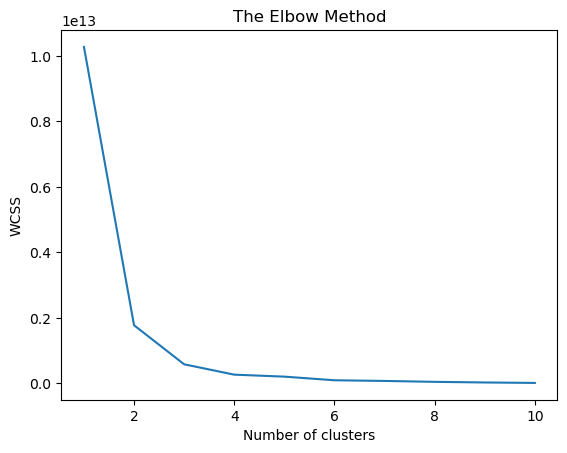

In [22]:
# Clustering dengan k-Means
inertia = []
for k in range(1, 11): # Mencoba jumlah cluster dari 2 hingga 10
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(Clust_data[fitur_clustering])
    inertia.append(kmeans.inertia_)

# Plot the graph to visualize the Elbow Method to find the optimal number of cluster
plt.plot(range(1,11),inertia)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [23]:
k_terbaik = 2 

kmeans = KMeans(n_clusters=k_terbaik, random_state=0)
kmeans.fit(Clust_data[fitur_clustering])
Clust_data['Cluster_kMeans'] = kmeans.labels_

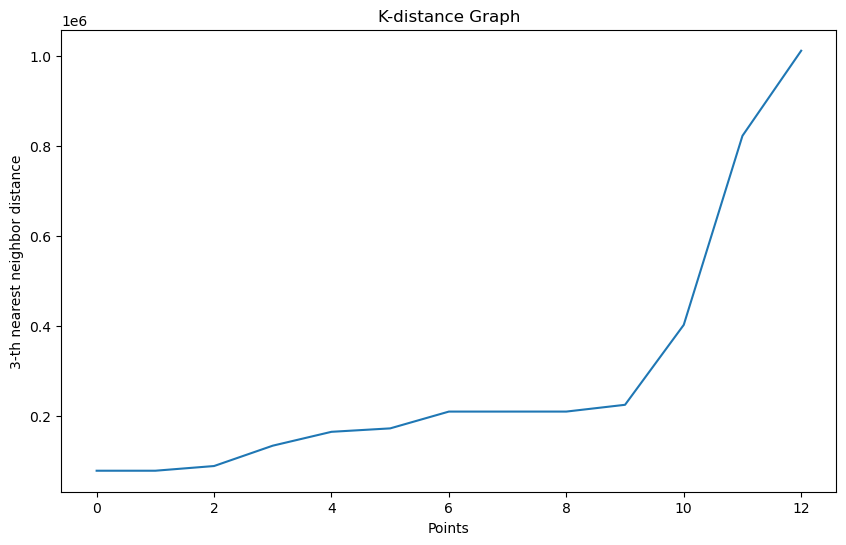

In [25]:
# Function to plot k-distance graph
def plot_k_distance_graph(X, k):
    neigh = NearestNeighbors(n_neighbors=k)
    neigh.fit(Clust_data[fitur_clustering])
    distances, _ = neigh.kneighbors(Clust_data[fitur_clustering])
    distances = np.sort(distances[:, k-1])
    plt.figure(figsize=(10, 6))
    plt.plot(distances)
    plt.xlabel('Points')
    plt.ylabel(f'{k}-th nearest neighbor distance')
    plt.title('K-distance Graph')
    plt.show()
# Plot k-distance graph
plot_k_distance_graph(Clust_data[fitur_clustering], k=3)

In [26]:
# Perform DBSCAN clustering
# Find optimal min_samples using Silhouette analysis
best_min_samples = 2  # Initialize
best_silhouette_score = -1

for min_samples in range(2, 99): # Test a range of min_samples
  dbscan = DBSCAN(eps=0.2, min_samples=min_samples) # Use the epsilon determined previously
  clusters = dbscan.fit_predict(Clust_data[fitur_clustering])

  # Check if the clustering resulted in more than one cluster and no all points are noise
  if len(set(clusters)) > 1 and -1 not in clusters or list(clusters).count(-1) < len(clusters):
    silhouette_avg = silhouette_score(Clust_data[fitur_clustering], clusters)
    if silhouette_avg > best_silhouette_score:
      best_silhouette_score = silhouette_avg
      best_min_samples = min_samples

print(f"Optimal min_samples based on Silhouette Score: {best_min_samples}")

# Perform DBSCAN clustering with the optimal min_samples
dbscan = DBSCAN(eps=0.2, min_samples=best_min_samples)
clusters = dbscan.fit_predict(Clust_data[fitur_clustering])
Clust_data['Cluster_DBSCAN'] = dbscan.labels_

Optimal min_samples based on Silhouette Score: 2


In [27]:
# 4. Tahap Deployment
# Calculate Silhouette Score for K-Means
silhouette_kmeans = silhouette_score(Clust_data[fitur_clustering], Clust_data['Cluster_kMeans'])
print(f"Silhouette Score for K-Means: {silhouette_kmeans}")

# Calculate Silhouette Score for DBSCAN
silhouette_dbscan = best_silhouette_score
print(f"Silhouette Score for DBSCAN: {silhouette_dbscan}")

# Compare the scores
if silhouette_kmeans > silhouette_dbscan:
    print("K-Means is the better clustering method based on Silhouette Score.")
elif silhouette_dbscan > silhouette_kmeans:
    print("DBSCAN is the better clustering method based on Silhouette Score.")
else:
    print("Both K-Means and DBSCAN have similar Silhouette Scores.")

Silhouette Score for K-Means: 0.7367520043042834
Silhouette Score for DBSCAN: -1
K-Means is the better clustering method based on Silhouette Score.


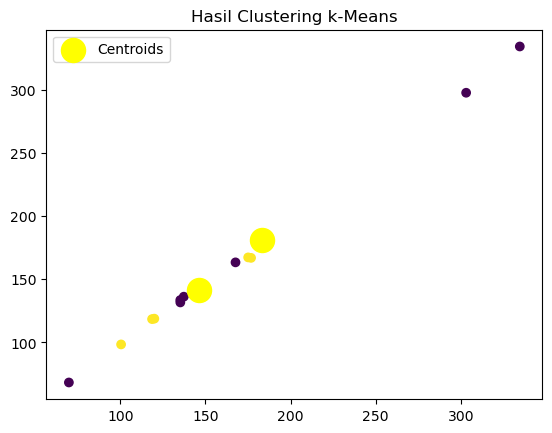

In [28]:
# Visualisasi hasil clustering
plt.scatter(Clust_data['Laki-Laki'], Clust_data['Perempuan'], c=Clust_data['Cluster_kMeans'], cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], s = 300, c = 'yellow', label = 'Centroids')
plt.title('Hasil Clustering k-Means')
plt.legend()
plt.show()